# MNIST Handwritten Digit Classification using LeNet-5

## Objective
Build and train a Convolutional Neural Network based on the LeNet-5 architecture for handwritten digit recognition on the MNIST dataset.

## Dataset
- MNIST
- 60,000 training images
- 10,000 testing images
- 10 classes (0-9)

## Technologies Used
- Python
- NumPy
- TensorFlow
- Keras
- Matplotlib

## Model Architecture
Input (32x32x1)
→ Conv2D(6, 5x5)
→ Average Pooling
→ Conv2D(16, 5x5)
→ Average Pooling
→ Flatten
→ Dense(120)
→ Dense(84)
→ Dense(10)

## Results
98.65%

In [1]:
import numpy as np
import tensorflow as tf

In [2]:
df=tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
(x_train,y_train),(x_test,y_test)=df

In [4]:
x_train.shape,y_train.shape,x_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [5]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0


In [6]:
x_train = np.pad(x_train, ((0, 0), (2, 2), (2, 2))) ##np.pad(array,image_height(28+2+2=32 //as lenet requires 32x32),image_width)
x_test  = np.pad(x_test,  ((0, 0), (2, 2), (2, 2)))

In [7]:
x_train=x_train[...,np.newaxis] #this adds color channel for confirmation check the shape of both x_train,x_test
x_test=x_test[...,np.newaxis]

In [8]:
x_train.shape,x_test.shape

((60000, 32, 32, 1), (10000, 32, 32, 1))

In [9]:
model=tf.keras.Sequential([tf.keras.layers.Input(shape=(32,32,1)),
          ##now before adding dense layer we will add the convolution layer then flatten it)
          tf.keras.layers.Conv2D(6,kernel_size=5,activation='tanh'),
          tf.keras.layers.AveragePooling2D(pool_size=2),
          tf.keras.layers.Conv2D(16,kernel_size=5,activation='tanh'),
          tf.keras.layers.AveragePooling2D(pool_size=2),
          tf.keras.layers.Flatten(),
          tf.keras.layers.Dense(120,activation='tanh'),
          tf.keras.layers.Dense(84,activation='tanh'),
          tf.keras.layers.Dense(10,activation="softmax")])


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [12]:
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,verbose=1,batch_size=64)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.9217 - loss: 0.2658 - val_accuracy: 0.9626 - val_loss: 0.1248
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.9680 - loss: 0.1018 - val_accuracy: 0.9747 - val_loss: 0.0835
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 40ms/step - accuracy: 0.9786 - loss: 0.0693 - val_accuracy: 0.9754 - val_loss: 0.0749
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.9840 - loss: 0.0504 - val_accuracy: 0.9807 - val_loss: 0.0644
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - accuracy: 0.9873 - loss: 0.0402 - val_accuracy: 0.9804 - val_loss: 0.0640
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.9898 - loss: 0.0329 - val_accuracy: 0.9831 - val_loss: 0.0516
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.9910 - loss: 0.0277 - val_accuracy: 0.9818 - val_loss: 0.0582
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.9929 - loss: 0.0229 - 

In [13]:
test_loss,test_acc=model.evaluate(x_test,y_test)
print(test_loss,test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9852 - loss: 0.0488
0.04884304478764534 0.9851999878883362


In [14]:
predictions=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [15]:
pred=np.argmax(predictions,axis=1)

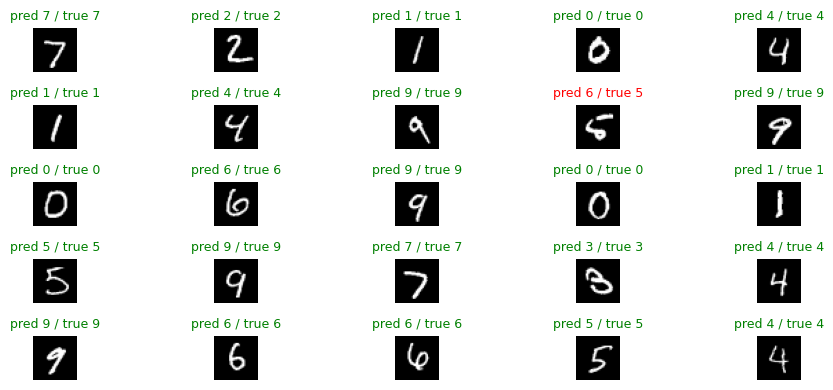

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_test[i].squeeze(), cmap="gray")  # squeeze drops the channel dim for display
    correct = (pred[i] == y_test[i])
    plt.title(f"pred {pred[i]} / true {y_test[i]}",
              color="green" if correct else "red", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
cm=tf.math.confusion_matrix(y_test,pred)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 972,    0,    0,    0,    0,    1,    2,    1,    4,    0],
       [   0, 1124,    0,    2,    1,    0,    4,    1,    3,    0],
       [   5,    1, 1021,    0,    1,    0,    0,    2,    2,    0],
       [   1,    0,    4,  990,    1,    3,    0,    3,    3,    5],
       [   0,    0,    3,    0,  970,    0,    3,    0,    0,    6],
       [   2,    0,    0,    4,    0,  882,    3,    0,    0,    1],
       [   4,    2,    1,    1,    8,    2,  938,    0,    2,    0],
       [   1,    2,    5,    2,    1,    0,    0, 1010,    3,    4],
       [   4,    0,    2,    3,    1,    2,    1,    2,  957,    2],
       [   1,    0,    0,    0,    8,    3,    2,    7,    0,  988]],
      dtype=int32)>